<a href="https://colab.research.google.com/github/UAMCAntwerpen/2040FBDBIC/blob/main/05_Molecular_similarity%2C_clustering_and_diversity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install RDKit

In [1]:
!pip install rdkit-pypi

     |████████████████████████████████| 18.6 MB 154 kB/s 


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

## Linear path-based FP's

10 bits ON out of the 10 bits in total
92 bits ON out of the 100 bits in total
223 bits ON out of the 1024 bits in total


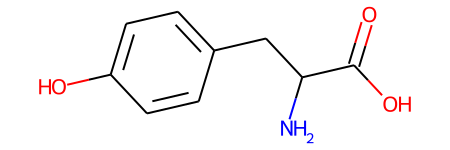

In [ ]:
mol = Chem.MolFromSmiles("Oc1ccc(CC(N)C(O)=O)cc1")

for fp_size in (10, 100, 1024):
  fp = Chem.RDKFingerprint(mol, fpSize=fp_size)
  print(len(list(fp.GetOnBits())), "bits ON out of the", len(fp), "bits in total")

mol

14 bits ON out of the 2048 bits in total
59 bits ON out of the 2048 bits in total
130 bits ON out of the 2048 bits in total
233 bits ON out of the 2048 bits in total


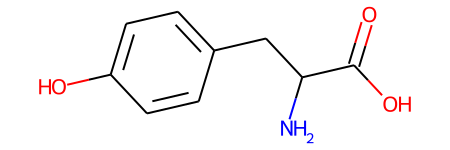

In [ ]:
mol = Chem.MolFromSmiles("Oc1ccc(CC(N)C(O)=O)cc1")

for max_path_length in (1,3,5,7):
  fp = Chem.RDKFingerprint(mol, maxPath=max_path_length)
  print(len(list(fp.GetOnBits())), "bits ON out of the", len(fp), "bits in total")

mol

## Circular FP's (ECFP)

Radius 1 : 11 bits ON out of the 1024 bits in total
Radius 2 : 16 bits ON out of the 1024 bits in total
Radius 3 : 17 bits ON out of the 1024 bits in total
Radius 4 : 17 bits ON out of the 1024 bits in total
Radius 5 : 17 bits ON out of the 1024 bits in total
Radius 6 : 17 bits ON out of the 1024 bits in total
Radius 7 : 17 bits ON out of the 1024 bits in total


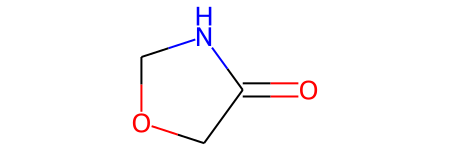

In [ ]:
from rdkit.Chem import AllChem
mol = Chem.MolFromSmiles("O1CC(=O)NC1")

for radius in range(1,8):
  fp = AllChem.GetMorganFingerprintAsBitVect(mol,radius,nBits=1024)
  print("Radius", radius, ":", len(list(fp.GetOnBits())), "bits ON out of the", len(fp), "bits in total")

mol

## MACCS keys

26 bits ON out of the 167 bits in total
[54, 84, 90, 95, 104, 111, 113, 123, 127, 131, 139, 143, 146, 151, 152, 154, 155, 156, 157, 158, 159, 161, 162, 163, 164, 165]


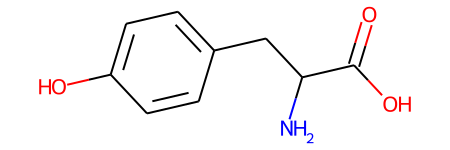

In [ ]:
from rdkit.Chem import MACCSkeys

mol = Chem.MolFromSmiles("Oc1ccc(CC(N)C(O)=O)cc1")
fp = MACCSkeys.GenMACCSKeys(mol)
print(len(list(fp.GetOnBits())), "bits ON out of the", len(fp), "bits in total")
print(list(fp.GetOnBits()))
mol

## Calculating similarity

In [ ]:
from rdkit import DataStructs

mol1 = Chem.MolFromSmiles("CCOC")
fp1 = Chem.RDKFingerprint(mol1, fpSize=50)
print(fp1.ToBitString())

mol2 = Chem.MolFromSmiles("CCO")
fp2 = Chem.RDKFingerprint(mol2, fpSize=50)
print(fp2.ToBitString())

tanimoto = DataStructs.FingerprintSimilarity(fp1, fp2)
print(tanimoto)

00000000101000001000001011010000000000000001000100
00000000001000001000000011010000000000000000000000
0.5555555555555556


In [ ]:
smiles = ["CO", "CCCO", "CCCOCCC"]
mols = []
for s in smiles: mols.append(Chem.MolFromSmiles(s))
fps = []
for mol in mols: fps.append(Chem.RDKFingerprint(mol))
ref = Chem.RDKFingerprint(Chem.MolFromSmiles("CCCO"))

for fp in fps:
  tversky = DataStructs.TverskySimilarity(ref, fp, 0.1, 0.9)
  print("%.2f" % tversky)

print()
for fp in fps:
  tversky = DataStructs.TverskySimilarity(ref, fp, 0.9, 0.1)
  print("%.2f" % tversky)


0.71
1.00
0.48

0.22
1.00
0.89


## Similarity in practice

In this exercise, a file with 10,000 compounds (SMILES format) is downloaded from the UAMC GitHub repo, and then a similarity search is performed to identify the compound that is most similar to aspirin ("CC(=O)OC1=CC=CC=C1C(=O)O")

0.570264765784114


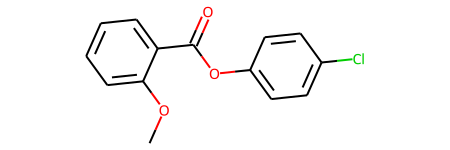

In [ ]:
# Download the SMILES file from GitHub
import requests
url = "https://raw.githubusercontent.com/UAMCAntwerpen/2040FBDBIC/main/compounds_10k.smi"
smiles = requests.get(url).text.split("\n")

# Aspirin is the query molecule
query = Chem.RDKFingerprint(Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O"))

# Loop over all molecules and keep the one with the highest similarity
max_sim = 0.0
best_hit = ""
for s in smiles:
  mol = Chem.MolFromSmiles(s)
  fp = Chem.RDKFingerprint(mol)
  tanimoto = DataStructs.FingerprintSimilarity(fp, query)
  if tanimoto >= max_sim:
    max_sim = tanimoto
    best_hit = s

# Show the best mol
mol = Chem.MolFromSmiles(best_hit) 
print(max_sim)
mol

Note: you can also use other similarity metrics such as the Tversky coefficient. Try this out to see how the results will alter.

## Maximal common substructure (MCSS)

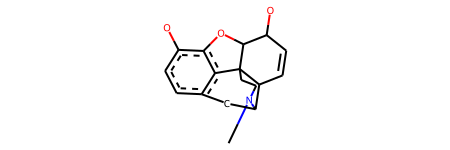

In [ ]:
from rdkit.Chem import rdFMCS

morphine = Chem.MolFromSmiles("CN1CC[C@]23C4=C5C=CC(O)=C4O[C@H]2[C@H](C=C[C@H]3[C@H]1C5)O")
codeine = Chem.MolFromSmiles("CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(O[C@H]3[C@@H](O)C=C4)=C(OC)C=C5")
heroine = Chem.MolFromSmiles("CN([C@H](CC(C=C1)=C23)[C@@H]4C=C[C@@H]5OC(C)=O)CC[C@]43[C@H]5OC2=C1OC(C)=O")

mols = [morphine, codeine, heroine]
mcss = rdFMCS.FindMCS(mols)
Chem.MolFromSmarts(mcss.smartsString)

In [ ]:
%%timeit
m1 = Chem.MolFromSmiles("C[C@H](C[C@@](C)(O1)[C@H](O[C@@H]2O[C@H](C)C[C@H](N(C)C)[C@H]2O)[C@@H](C)[C@H](O[C@H]3C[C@@](C)(OC)[C@@H](O)[C@H](C)O3)[C@H]4C)[C@@]1([H])[C@H](C)[C@H](C(C)=O)OC4=O")
m2 = Chem.MolFromSmiles("C[C@H]1[C@@H](O[C@@H]2O[C@@H](C)[C@H](O)[C@@](OC)(C)C2)[C@H](C)[C@H](O[C@@H]3O[C@H](C)C[C@H](N(C)C)[C@H]3O)[C@@](O)(C)C[C@H](C)[C@H](N)[C@H](C)CN(C)CCOC1=O")

mols = [m1, m2]
mcss = rdFMCS.FindMCS(mols)

1 loop, best of 5: 8.07 s per loop


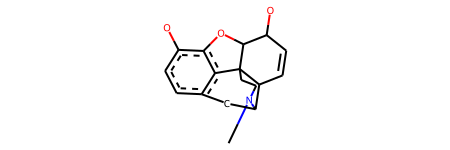

In [ ]:
Chem.MolFromSmarts(mcss.smartsString)

## Clustering

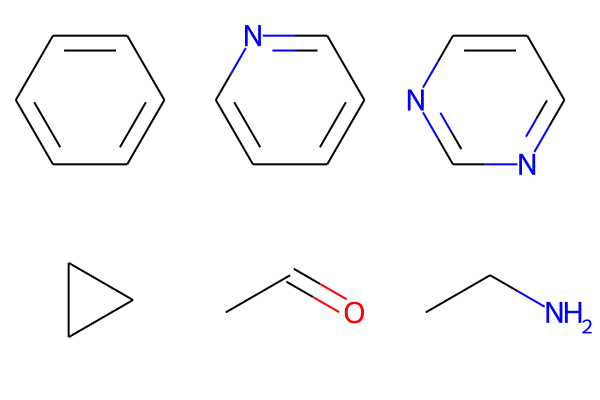

In [ ]:
# Six molecules
smiles = ["c1ccccc1", "c1cccnc1", "c1ncncc1", "C1CC1", "CC=O", "NCC"]
mols = [Chem.MolFromSmiles(x) for x in smiles]
fps = [AllChem.GetMorganFingerprintAsBitVect(x, 2, nBits=20) for x in mols]
display(Draw.MolsToGridImage(mols, molsPerRow=3))

In [ ]:
import numpy as np

# Show the fingerprints
for i in range(len(fps)): print("%s %s" % (fps[i].ToBitString(), smiles[i]))

00001000010001000000 c1ccccc1
00011101011001100001 c1cccnc1
00011100011001100100 c1ncncc1
10000000000000100000 C1CC1
00000000001000001110 CC=O
00000100000010100101 NCC


In [ ]:
# Convert to format which is useable by clustering algorithm
nps = [np.array(x) for x in fps]
X = np.array(nps)
print(X)

[[0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 0 0 0 0 1]
 [0 0 0 1 1 1 0 0 0 1 1 0 0 1 1 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1]]


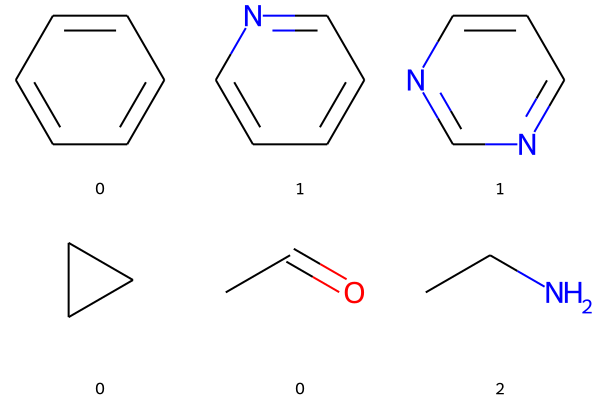

In [ ]:
# Hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
clusterEngine = AgglomerativeClustering(n_clusters = 3)
clusterEngine.fit(X)

labels = [str(x) for x in clusterEngine.labels_]
display(Draw.MolsToGridImage(mols, molsPerRow=3, legends=labels))

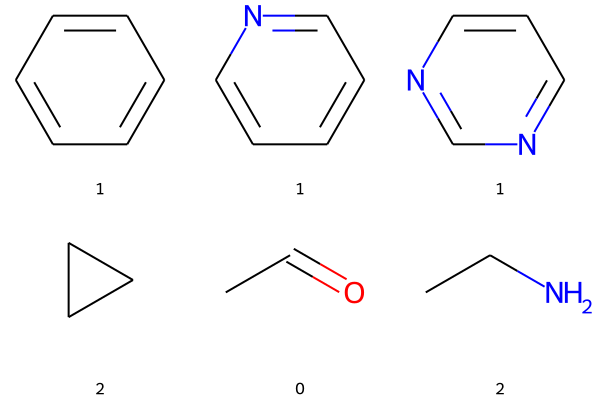

In [ ]:
# Non-hierarchical clustering: k-means
from sklearn.cluster import KMeans
clusterEngine = KMeans(n_clusters = 3)
clusterEngine.fit(X)

labels = [str(x) for x in clusterEngine.labels_]
display(Draw.MolsToGridImage(mols, molsPerRow=3, legends=labels))

In [ ]:
centers = clusterEngine.cluster_centers_
print(centers)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         1.         0.
  0.         0.         0.         0.         1.         1.
  1.         0.        ]
 [0.         0.         0.         0.66666667 1.         0.66666667
  0.         0.33333333 0.         1.         0.66666667 0.
  0.         1.         0.66666667 0.         0.         0.33333333
  0.         0.33333333]
 [0.5        0.         0.         0.         0.         0.5
  0.         0.         0.         0.         0.         0.
  0.5        0.         1.         0.         0.         0.5
  0.         0.5       ]]
